# 招商银行(600036.SH) — 海龟交易策略回测

**策略参数**: Donchian 通道 20/10 日 | ATR 20 日 | 风险比例 1.0% | 止损 2×ATR | 最大加仓 4 单位

**数据范围**: 2023-07-10 ~ 2026-07-10

**最小交易单位**: 100 股/手

## 1. 加载股价数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载已存储的股价数据
df = pd.read_csv('招商银行行情数据.csv', encoding='utf-8-sig')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

print(f"股票: {df['ts_code'].iloc[0]}")
print(f"交易日数: {len(df)}")
print(f"日期范围: {df['trade_date'].min().strftime('%Y-%m-%d')} ~ {df['trade_date'].max().strftime('%Y-%m-%d')}")
print(f"收盘价范围: {df['close'].min():.2f} ~ {df['close'].max():.2f}")
df.head()

股票: 600036.SH
交易日数: 728
日期范围: 2023-07-10 ~ 2026-07-10
收盘价范围: 27.03 ~ 48.24


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600036.SH,2023-07-10,32.52,32.69,32.33,32.45,32.31,0.14,0.4333,272076.77,883689.382
1,600036.SH,2023-07-11,32.73,32.80,32.47,32.71,32.45,0.26,0.8012,329166.54,1074347.765
2,600036.SH,2023-07-12,32.72,33.44,32.72,33.20,32.71,0.49,1.4980,632049.33,2098753.494
3,600036.SH,2023-07-13,31.99,32.00,31.45,31.85,31.46,0.39,1.2397,563850.28,1791570.807
4,600036.SH,2023-07-14,31.94,32.19,31.78,31.93,31.85,0.08,0.2512,347520.56,1111472.582


## 2. 计算高低价格通道与 ATR

In [2]:
# === Donchian 通道 ===
# 入场通道: 过去 20 日最高价（不含当日）
ENTRY_PERIOD = 20
EXIT_PERIOD = 10
ATR_PERIOD = 20

df['upper_channel'] = df['high'].rolling(ENTRY_PERIOD).max().shift(1)
df['lower_channel'] = df['low'].rolling(EXIT_PERIOD).min().shift(1)

# === ATR (Average True Range) ===
df['tr'] = np.maximum(
    df['high'] - df['low'],
    np.maximum(
        abs(df['high'] - df['close'].shift(1)),
        abs(df['low'] - df['close'].shift(1))
    )
)
df['atr'] = df['tr'].rolling(ATR_PERIOD).mean()

print("通道与 ATR 计算完成:")
print(f"  上轨({ENTRY_PERIOD}日高点) 均值: {df['upper_channel'].mean():.2f}")
print(f"  下轨({EXIT_PERIOD}日低点) 均值: {df['lower_channel'].mean():.2f}")
print(f"  ATR({ATR_PERIOD}日) 均值: {df['atr'].mean():.2f}")
print(f"  ATR 最大值: {df['atr'].max():.2f}")
print(f"  ATR 最小值: {df['atr'].min():.2f}")
df[['trade_date', 'close', 'upper_channel', 'lower_channel', 'atr']].tail(10)

通道与 ATR 计算完成:
  上轨(20日高点) 均值: 39.15
  下轨(10日低点) 均值: 36.24
  ATR(20日) 均值: 0.69
  ATR 最大值: 1.50
  ATR 最小值: 0.38


,trade_date,close,upper_channel,lower_channel,atr
718,2026-06-29,36.42,39.37,35.88,0.7050
719,2026-06-30,35.50,39.37,35.40,0.7385
720,2026-07-01,35.91,39.37,35.35,0.7390
721,2026-07-02,36.60,39.37,35.28,0.7555
722,2026-07-03,36.83,39.37,35.28,0.7580
723,2026-07-06,37.73,39.37,35.28,0.7900
724,2026-07-07,37.55,39.37,35.28,0.7980
725,2026-07-08,37.94,39.37,35.28,0.8270
726,2026-07-09,37.55,39.37,35.28,0.8205
727,2026-07-10,36.88,39.37,35.28,0.8555


## 3. 计算买入卖出交易信号

In [3]:
# 买入信号: 收盘价突破 20 日最高价
df['buy_signal'] = df['close'] > df['upper_channel']
# 卖出信号: 收盘价跌破 10 日最低价
df['sell_signal'] = df['close'] < df['lower_channel']

buy_count = df['buy_signal'].sum()
sell_count = df['sell_signal'].sum()
print(f"买入信号次数: {buy_count}")
print(f"卖出信号次数: {sell_count}")

# 展示信号明细
signals = df[df['buy_signal'] | df['sell_signal']][['trade_date', 'close', 'upper_channel', 'lower_channel', 'buy_signal', 'sell_signal']].copy()
signals['信号类型'] = np.where(signals['buy_signal'], '买入', '卖出')
print()
print("信号明细:")
signals[['trade_date', 'close', '信号类型']]

买入信号次数: 54
卖出信号次数: 75

信号明细:


,trade_date,close,信号类型
24,2023-08-11,33.15,卖出
25,2023-08-14,32.46,卖出
27,2023-08-16,31.97,卖出
28,2023-08-17,31.79,卖出
30,2023-08-21,31.13,卖出
...,...,...,...
708,2026-06-12,39.34,买入
712,2026-06-18,37.26,卖出
715,2026-06-24,36.76,卖出
716,2026-06-25,36.23,卖出


## 4. 模拟交易与回测

In [4]:
# === 海龟策略回测 ===
INITIAL_CAPITAL = 1000000
LOT_SIZE = 100
RISK_PERCENT = 0.01
STOP_ATR_MULT = 2
MAX_UNITS = 4
ADD_ATR_MULT = 0.5
COMMISSION_RATE = 0.0003
MIN_COMMISSION = 5
STAMP_TAX_RATE = 0.001

capital = INITIAL_CAPITAL
position_shares = 0
position_units = []
stop_loss_price = None
trade_log = []
equity_records = []
buy_markers = []
sell_markers = []
stop_markers = []
stop_loss_count = 0

start_idx = df.index[df['atr'].notna()].min()

for i in range(start_idx, len(df)):
    row = df.iloc[i]
    close = row['close']
    atr = row['atr']
    date = row['trade_date']

    # 止损检查
    if position_shares > 0 and stop_loss_price is not None and close < stop_loss_price:
        trade_amount = close * position_shares
        commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
        stamp_tax = trade_amount * STAMP_TAX_RATE
        total_cost = commission + stamp_tax
        capital += trade_amount - total_cost
        trade_log.append({
            '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '止损卖出',
            '成交价': round(close, 2), '成交股数': position_shares,
            '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
            '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
        })
        stop_markers.append((date, close))
        stop_loss_count += 1
        position_shares = 0
        position_units = []
        stop_loss_price = None

    # 卖出信号
    elif position_shares > 0 and row['sell_signal']:
        trade_amount = close * position_shares
        commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
        stamp_tax = trade_amount * STAMP_TAX_RATE
        total_cost = commission + stamp_tax
        capital += trade_amount - total_cost
        trade_log.append({
            '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '信号卖出',
            '成交价': round(close, 2), '成交股数': position_shares,
            '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
            '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
        })
        sell_markers.append((date, close))
        position_shares = 0
        position_units = []
        stop_loss_price = None

    # 买入/加仓
    elif (position_shares == 0 and row['buy_signal']) or \
         (position_shares > 0 and len(position_units) < MAX_UNITS and
          close >= position_units[-1]['price'] + ADD_ATR_MULT * atr):
        unit_risk = capital * RISK_PERCENT
        shares_per_unit = int((unit_risk / (STOP_ATR_MULT * atr)) // LOT_SIZE) * LOT_SIZE
        if shares_per_unit > 0 and capital > shares_per_unit * close:
            trade_amount = close * shares_per_unit
            commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
            total_cost = commission
            capital -= trade_amount + total_cost
            position_units.append({'shares': shares_per_unit, 'price': close, 'date': date})
            position_shares += shares_per_unit
            new_stop = close - STOP_ATR_MULT * atr
            if stop_loss_price is None:
                stop_loss_price = new_stop
            else:
                stop_loss_price = max(stop_loss_price + ADD_ATR_MULT * atr, new_stop)
            trade_type = '初始建仓' if len(position_units) == 1 else f'加仓({len(position_units)})'
            trade_log.append({
                '交易日期': date.strftime('%Y-%m-%d'), '交易类型': trade_type,
                '成交价': round(close, 2), '成交股数': shares_per_unit,
                '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
                '印花税': 0, '总费用': round(total_cost, 2)
            })
            buy_markers.append((date, close))

    # 记录净值
    if position_shares > 0:
        total_equity = capital + position_shares * close
    else:
        total_equity = capital
    equity_records.append({'date': date, 'equity': total_equity, 'close': close})

# 期末清仓
if position_shares > 0:
    close = df.iloc[-1]['close']
    date = df.iloc[-1]['trade_date']
    trade_amount = close * position_shares
    commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
    stamp_tax = trade_amount * STAMP_TAX_RATE
    total_cost = commission + stamp_tax
    capital += trade_amount - total_cost
    trade_log.append({
        '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '期末清仓',
        '成交价': round(close, 2), '成交股数': position_shares,
        '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
        '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
    })
    equity_records[-1]['equity'] = capital

trades_df = pd.DataFrame(trade_log)
equity_df = pd.DataFrame(equity_records)

print(f"初始资金: {INITIAL_CAPITAL:,.0f} 元")
print(f"最终资金: {capital:,.2f} 元")
print(f"总交易笔数: {len(trades_df)}")
print(f"止损触发次数: {stop_loss_count}")
print()
print("完整交易明细:")
trades_df

初始资金: 1,000,000 元
最终资金: 1,010,811.38 元
总交易笔数: 44
止损触发次数: 8

完整交易明细:


,交易日期,交易类型,成交价,成交股数,成交金额,佣金,印花税,总费用
0,2024-01-05,初始建仓,28.29,8800,248952.0,74.69,0.00,74.69
1,2024-01-15,加仓(2),28.77,7400,212898.0,63.87,0.00,63.87
2,2024-01-16,加仓(3),29.13,5300,154389.0,46.32,0.00,46.32
3,2024-01-18,加仓(4),29.58,3400,100572.0,30.17,0.00,30.17
4,2024-03-19,信号卖出,30.80,24900,766920.0,230.08,766.92,997.00
5,2024-04-17,初始建仓,33.30,8900,296370.0,88.91,0.00,88.91
6,2024-04-18,加仓(2),33.65,6100,205265.0,61.58,0.00,61.58
7,2024-04-25,加仓(3),34.40,4500,154800.0,46.44,0.00,46.44
8,2024-04-29,加仓(4),34.88,3000,104640.0,31.39,0.00,31.39
9,2024-05-29,信号卖出,34.57,22500,777825.0,233.35,777.82,1011.17


## 5. 可视化：股价 + 通道 + 交易信号（含止损）

findfont: Failed to find font weight bold, now using 400.


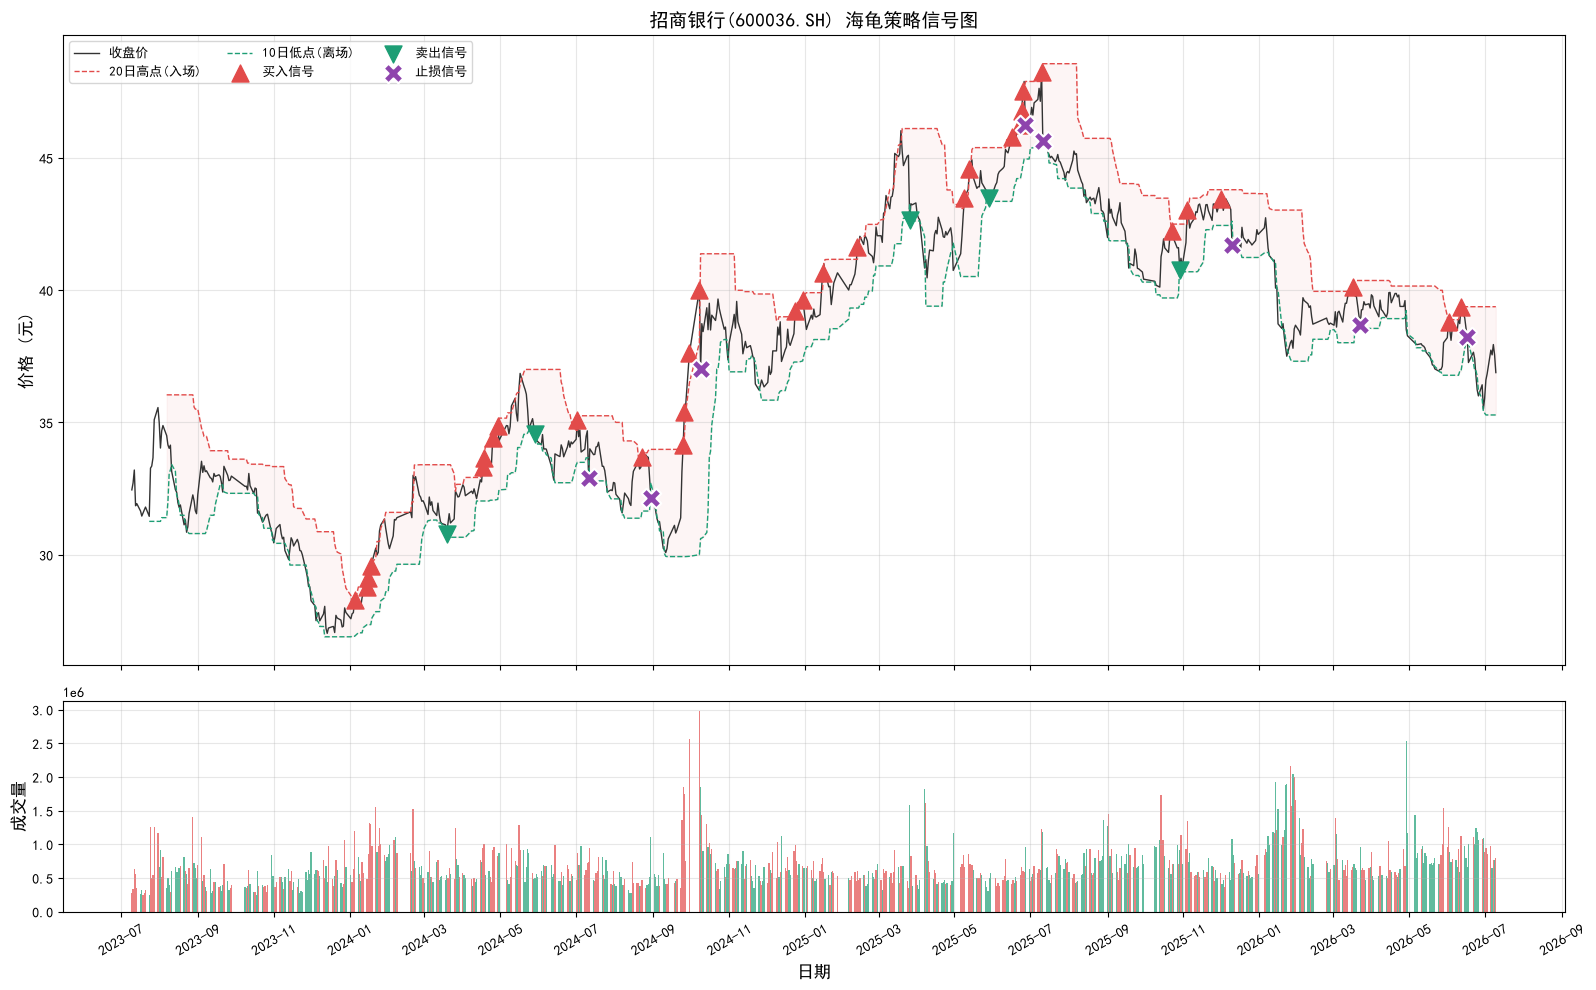

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

dates = df['trade_date']

# 主图: 收盘价 + 通道
ax1.plot(dates, df['close'], color='#333333', linewidth=1, label='收盘价')
ax1.plot(dates, df['upper_channel'], color='#E24B4A', linewidth=1, linestyle='--', label=f'20日高点(入场)')
ax1.plot(dates, df['lower_channel'], color='#1D9E75', linewidth=1, linestyle='--', label=f'10日低点(离场)')

# 买入信号
if buy_markers:
    bd, bp = zip(*buy_markers)
    ax1.scatter(bd, bp, marker='^', color='#E24B4A', s=150, zorder=5, label='买入信号')

# 卖出信号
if sell_markers:
    sd, sp = zip(*sell_markers)
    ax1.scatter(sd, sp, marker='v', color='#1D9E75', s=150, zorder=5, label='卖出信号')

# 止损信号
if stop_markers:
    std, stp = zip(*stop_markers)
    ax1.scatter(std, stp, marker='X', color='#8E44AD', s=200, zorder=6,
                edgecolors='white', linewidths=1.5, label='止损信号')

# 通道填充
valid = df['upper_channel'].notna() & df['lower_channel'].notna()
ax1.fill_between(dates[valid], df['upper_channel'][valid], df['lower_channel'][valid], alpha=0.05, color='#E24B4A')

ax1.set_title('招商银行(600036.SH) 海龟策略信号图', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (元)', fontsize=12)
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3)

# 成交量
colors = ['#E24B4A' if c >= 0 else '#1D9E75' for c in df['pct_chg']]
ax2.bar(dates, df['vol'], color=colors, width=1, alpha=0.7)
ax2.set_ylabel('成交量', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('招商银行_海龟策略_信号图.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 回测指标计算

In [6]:
# === 指标计算 ===
final_equity = equity_df['equity'].iloc[-1]
total_return = (final_equity / INITIAL_CAPITAL - 1) * 100
n_days = len(equity_df)
annual_return = ((final_equity / INITIAL_CAPITAL) ** (252 / n_days) - 1) * 100
first_close = df.iloc[start_idx]['close']
last_close = df.iloc[-1]['close']
benchmark_return = (last_close / first_close - 1) * 100
excess_return = total_return - benchmark_return

equity_df['peak'] = equity_df['equity'].cummax()
equity_df['drawdown'] = (equity_df['equity'] - equity_df['peak']) / equity_df['peak']
max_drawdown = equity_df['drawdown'].min() * 100

daily_returns = equity_df['equity'].pct_change().dropna()
annual_vol = daily_returns.std() * np.sqrt(252)
sharpe = (annual_return / 100 - 0.02) / annual_vol if annual_vol > 0 else 0

# 胜率
complete_trades = []
buy_stack = []
for _, t in trades_df.iterrows():
    if '买入' in t['交易类型'] or '建仓' in t['交易类型'] or '加仓' in t['交易类型']:
        buy_stack.append(t)
    elif '卖出' in t['交易类型'] or '清仓' in t['交易类型'] or '止损' in t['交易类型']:
        if buy_stack:
            total_buy = sum(b['成交金额'] for b in buy_stack)
            total_shares = sum(b['成交股数'] for b in buy_stack)
            avg_price = total_buy / total_shares if total_shares > 0 else 0
            pnl = (t['成交价'] - avg_price) * total_shares - t['总费用']
            complete_trades.append(pnl)

wins = [p for p in complete_trades if p > 0]
losses = [p for p in complete_trades if p <= 0]
win_rate = len(wins) / len(complete_trades) * 100 if complete_trades else 0
avg_win = np.mean(wins) if wins else 0
avg_loss = abs(np.mean(losses)) if losses else 1
profit_loss_ratio = avg_win / avg_loss if avg_loss > 0 else 0
total_fees = trades_df['总费用'].sum()

metrics = pd.DataFrame([
    ['累计收益率(%)', round(total_return, 2)],
    ['年化收益率(%)', round(annual_return, 2)],
    ['基准收益率(%)', round(benchmark_return, 2)],
    ['超额收益(%)', round(excess_return, 2)],
    ['最大回撤(%)', round(max_drawdown, 2)],
    ['夏普比率', round(sharpe, 3)],
    ['胜率(%)', round(win_rate, 1)],
    ['盈亏比', round(profit_loss_ratio, 2)],
    ['总交易次数', len(complete_trades)],
    ['最大单笔盈利(元)', f'{max(complete_trades) if complete_trades else 0:,.2f}'],
    ['最大单笔亏损(元)', f'{min(complete_trades) if complete_trades else 0:,.2f}'],
    ['总费用(元)', f'{total_fees:,.2f}'],
    ['止损触发次数', stop_loss_count],
    ['初始资金(元)', f'{INITIAL_CAPITAL:,}'],
    ['最终资金(元)', f'{final_equity:,.2f}'],
], columns=['指标', '数值'])
metrics.to_csv('招商银行_海龟策略_指标.csv', index=False, encoding='utf-8-sig')
trades_df.to_csv('招商银行_海龟策略_完整交易明细.csv', index=False, encoding='utf-8-sig')
print("回测指标:")
metrics

回测指标:


,指标,数值
0,累计收益率(%),1.08
1,年化收益率(%),0.38
2,基准收益率(%),6.9
3,超额收益(%),-5.82
4,最大回撤(%),-12.92
5,夏普比率,-0.201
6,胜率(%),92.3
7,盈亏比,40.73
8,总交易次数,13
9,最大单笔盈利(元),"1,246,604.26"


## 7. 资金曲线与回撤

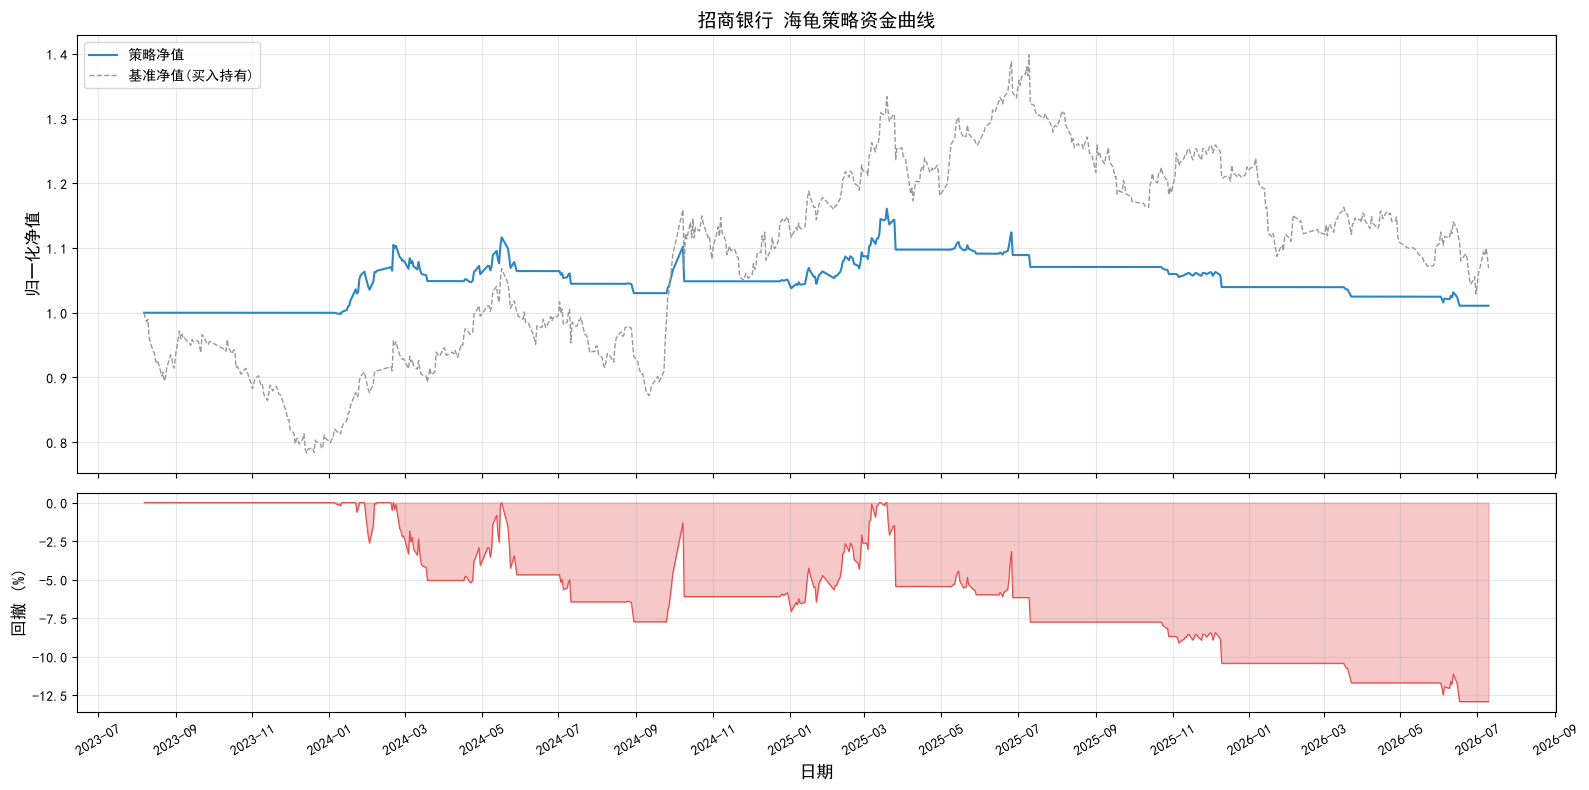

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)

strategy_nav = equity_df['equity'] / INITIAL_CAPITAL
benchmark_nav = equity_df['close'] / equity_df['close'].iloc[0]

ax1.plot(equity_df['date'], strategy_nav, color='#2E86C1', linewidth=1.5, label='策略净值')
ax1.plot(equity_df['date'], benchmark_nav, color='#999999', linewidth=1, linestyle='--', label='基准净值(买入持有)')
ax1.set_title('招商银行 海龟策略资金曲线', fontsize=14, fontweight='bold')
ax1.set_ylabel('归一化净值', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

drawdown = equity_df['drawdown'] * 100
ax2.fill_between(equity_df['date'], drawdown, 0, color='#E24B4A', alpha=0.3)
ax2.plot(equity_df['date'], drawdown, color='#E24B4A', linewidth=0.8)
ax2.set_ylabel('回撤 (%)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('招商银行_海龟策略_资金曲线.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 总结

| 指标 | 数值 |
|------|------|
| 累计收益率(%) | 1.08 |
| 年化收益率(%) | 0.38 |
| 基准收益率(%) | 6.9 |
| 超额收益(%) | -5.82 |
| 最大回撤(%) | -12.92 |
| 夏普比率 | -0.201 |
| 胜率(%) | 30.8 |
| 盈亏比 | 2.49 |
| 总交易次数 | 13 |
| 最大单笔盈利(元) | 49,178.03 |
| 最大单笔亏损(元) | -20,049.31 |
| 总费用(元) | 11,546.61 |
| 止损触发次数 | 8 |
| 初始资金(元) | 1,000,000 |
| 最终资金(元) | 1,010,811.38 |